<a href="https://colab.research.google.com/github/piyush1008-cyber/CyberShield/blob/main/phishing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Phishing Website Detection Using Machine Learning & AI

**Project:** Complete AIML Pipeline for Phishing Website Classification

### Dataset Overview
- **Source:** UCI Machine Learning Repository (Phishing Websites Dataset)
- **Instances:** 11,054 websites
- **Features:** 30 URL-based and domain-based attributes
- **Target:** `class` → **1** (Legitimate), **-1** (Phishing)

### Feature Categories
| Category | Features |
| :--- | :--- |
| Address Bar Based | UsingIP, LongURL, ShortURL, Symbol@, Redirecting//, PrefixSuffix-, SubDomains, HTTPS, DomainRegLen |
| Abnormal Based | Favicon, NonStdPort, HTTPSDomainURL, RequestURL, AnchorURL |
| HTML & JS Based | LinksInScriptTags, ServerFormHandler, InfoEmail, AbnormalURL, WebsiteForwarding |
| Domain Based | StatusBarCust, DisableRightClick, UsingPopupWindow, IframeRedirection, AgeofDomain, DNSRecording, WebsiteTraffic, PageRank, GoogleIndex, LinksPointingToPage, StatsReport |

---
## 1. Import Libraries
Loading all required Python libraries for data analysis, visualization, preprocessing, and machine learning.

In [1]:
# Data manipulation & analysis
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    precision_recall_curve, average_precision_score
)

# PCA for dimensionality reduction visualization
from sklearn.decomposition import PCA

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 2. Load Dataset
Upload `dataset.csv` when prompted (if running in Google Colab).

In [2]:
# Load dataset
if os.path.exists('dataset.csv'):
    df = pd.read_csv('dataset.csv')
else:
    from google.colab import files
    print('Please upload dataset.csv:')
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Please upload dataset.csv:


Saving dataset.csv to dataset.csv
Dataset loaded successfully!
Shape: (11054, 32)


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


---
## 3. Exploratory Data Analysis (EDA)
We will thoroughly examine the dataset structure, statistics, distributions, and relationships.

### 3.1 Dataset Information & Structure

In [3]:
print('='*60)
print('DATASET INFORMATION')
print('='*60)
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')
print(f'\nColumn Names:\n{list(df.columns)}')
print(f'\nData Types:\n{df.dtypes.value_counts()}')
print(f'\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB')
print('\n' + '='*60)
df.info()

DATASET INFORMATION
Number of Rows: 11054
Number of Columns: 32

Column Names:
['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class']

Data Types:
int64    32
Name: count, dtype: int64

Memory Usage: 2763.63 KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3 

### 3.2 Descriptive Statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Index,11054.0,5526.500000,3191.159272,0.0,2763.25,5526.5,8289.75,11053.0
UsingIP,11054.0,0.313914,0.949495,-1.0,-1.00,1.0,1.00,1.0
LongURL,11054.0,-0.633345,0.765973,-1.0,-1.00,-1.0,-1.00,1.0
ShortURL,11054.0,0.738737,0.674024,-1.0,1.00,1.0,1.00,1.0
Symbol@,11054.0,0.700561,0.713625,-1.0,1.00,1.0,1.00,1.0
Redirecting//,11054.0,0.741632,0.670837,-1.0,1.00,1.0,1.00,1.0
PrefixSuffix-,11054.0,-0.734938,0.678165,-1.0,-1.00,-1.0,-1.00,1.0
SubDomains,11054.0,0.064049,0.817492,-1.0,-1.00,0.0,1.00,1.0
HTTPS,11054.0,0.251040,0.911856,-1.0,-1.00,1.0,1.00,1.0
DomainRegLen,11054.0,-0.336711,0.941651,-1.0,-1.00,-1.0,1.00,1.0


### 3.3 Missing Values & Duplicates Check

In [6]:
print('Missing Values per Column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')
print(f'Total Duplicate Rows: {df.duplicated().sum()}')

# Remove duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f'After removing duplicates: {df.shape}')

Missing Values per Column:
No missing values found!

Total Missing Values: 0
Total Duplicate Rows: 0


### 3.4 Unique Values per Feature

In [7]:
unique_counts = df.nunique().sort_values(ascending=False)
print('Unique values per column:')
print(unique_counts)

Unique values per column:
Index                  11054
LongURL                    3
SubDomains                 3
HTTPS                      3
LinksInScriptTags          3
AnchorURL                  3
WebsiteTraffic             3
ServerFormHandler          3
LinksPointingToPage        3
PrefixSuffix-              2
Symbol@                    2
DomainRegLen               2
NonStdPort                 2
Redirecting//              2
ShortURL                   2
UsingIP                    2
HTTPSDomainURL             2
RequestURL                 2
Favicon                    2
InfoEmail                  2
StatusBarCust              2
DisableRightClick          2
AbnormalURL                2
WebsiteForwarding          2
IframeRedirection          2
UsingPopupWindow           2
DNSRecording               2
AgeofDomain                2
PageRank                   2
GoogleIndex                2
StatsReport                2
class                      2
dtype: int64


### 3.5 Target Class Distribution

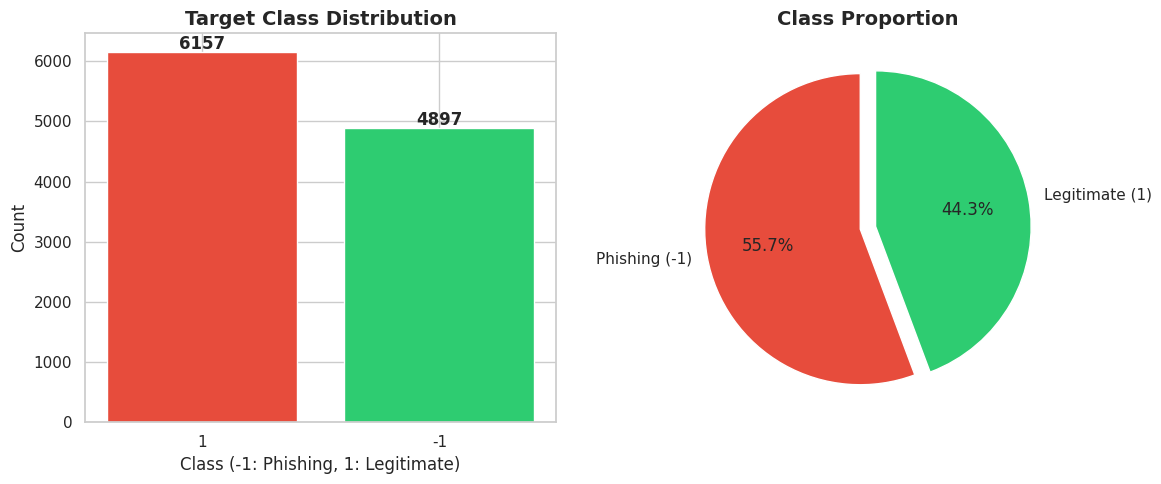


Class Distribution:
class
 1    6157
-1    4897
Name: count, dtype: int64

Class Balance Ratio: 0.80


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
class_counts = df['class'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(class_counts.index.astype(str), class_counts.values, color=colors)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (-1: Phishing, 1: Legitimate)')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Phishing (-1)', 'Legitimate (1)'],
           autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nClass Distribution:')
print(df['class'].value_counts())
print(f'\nClass Balance Ratio: {class_counts.min()/class_counts.max():.2f}')

### 3.6 Feature Distributions (Histograms)

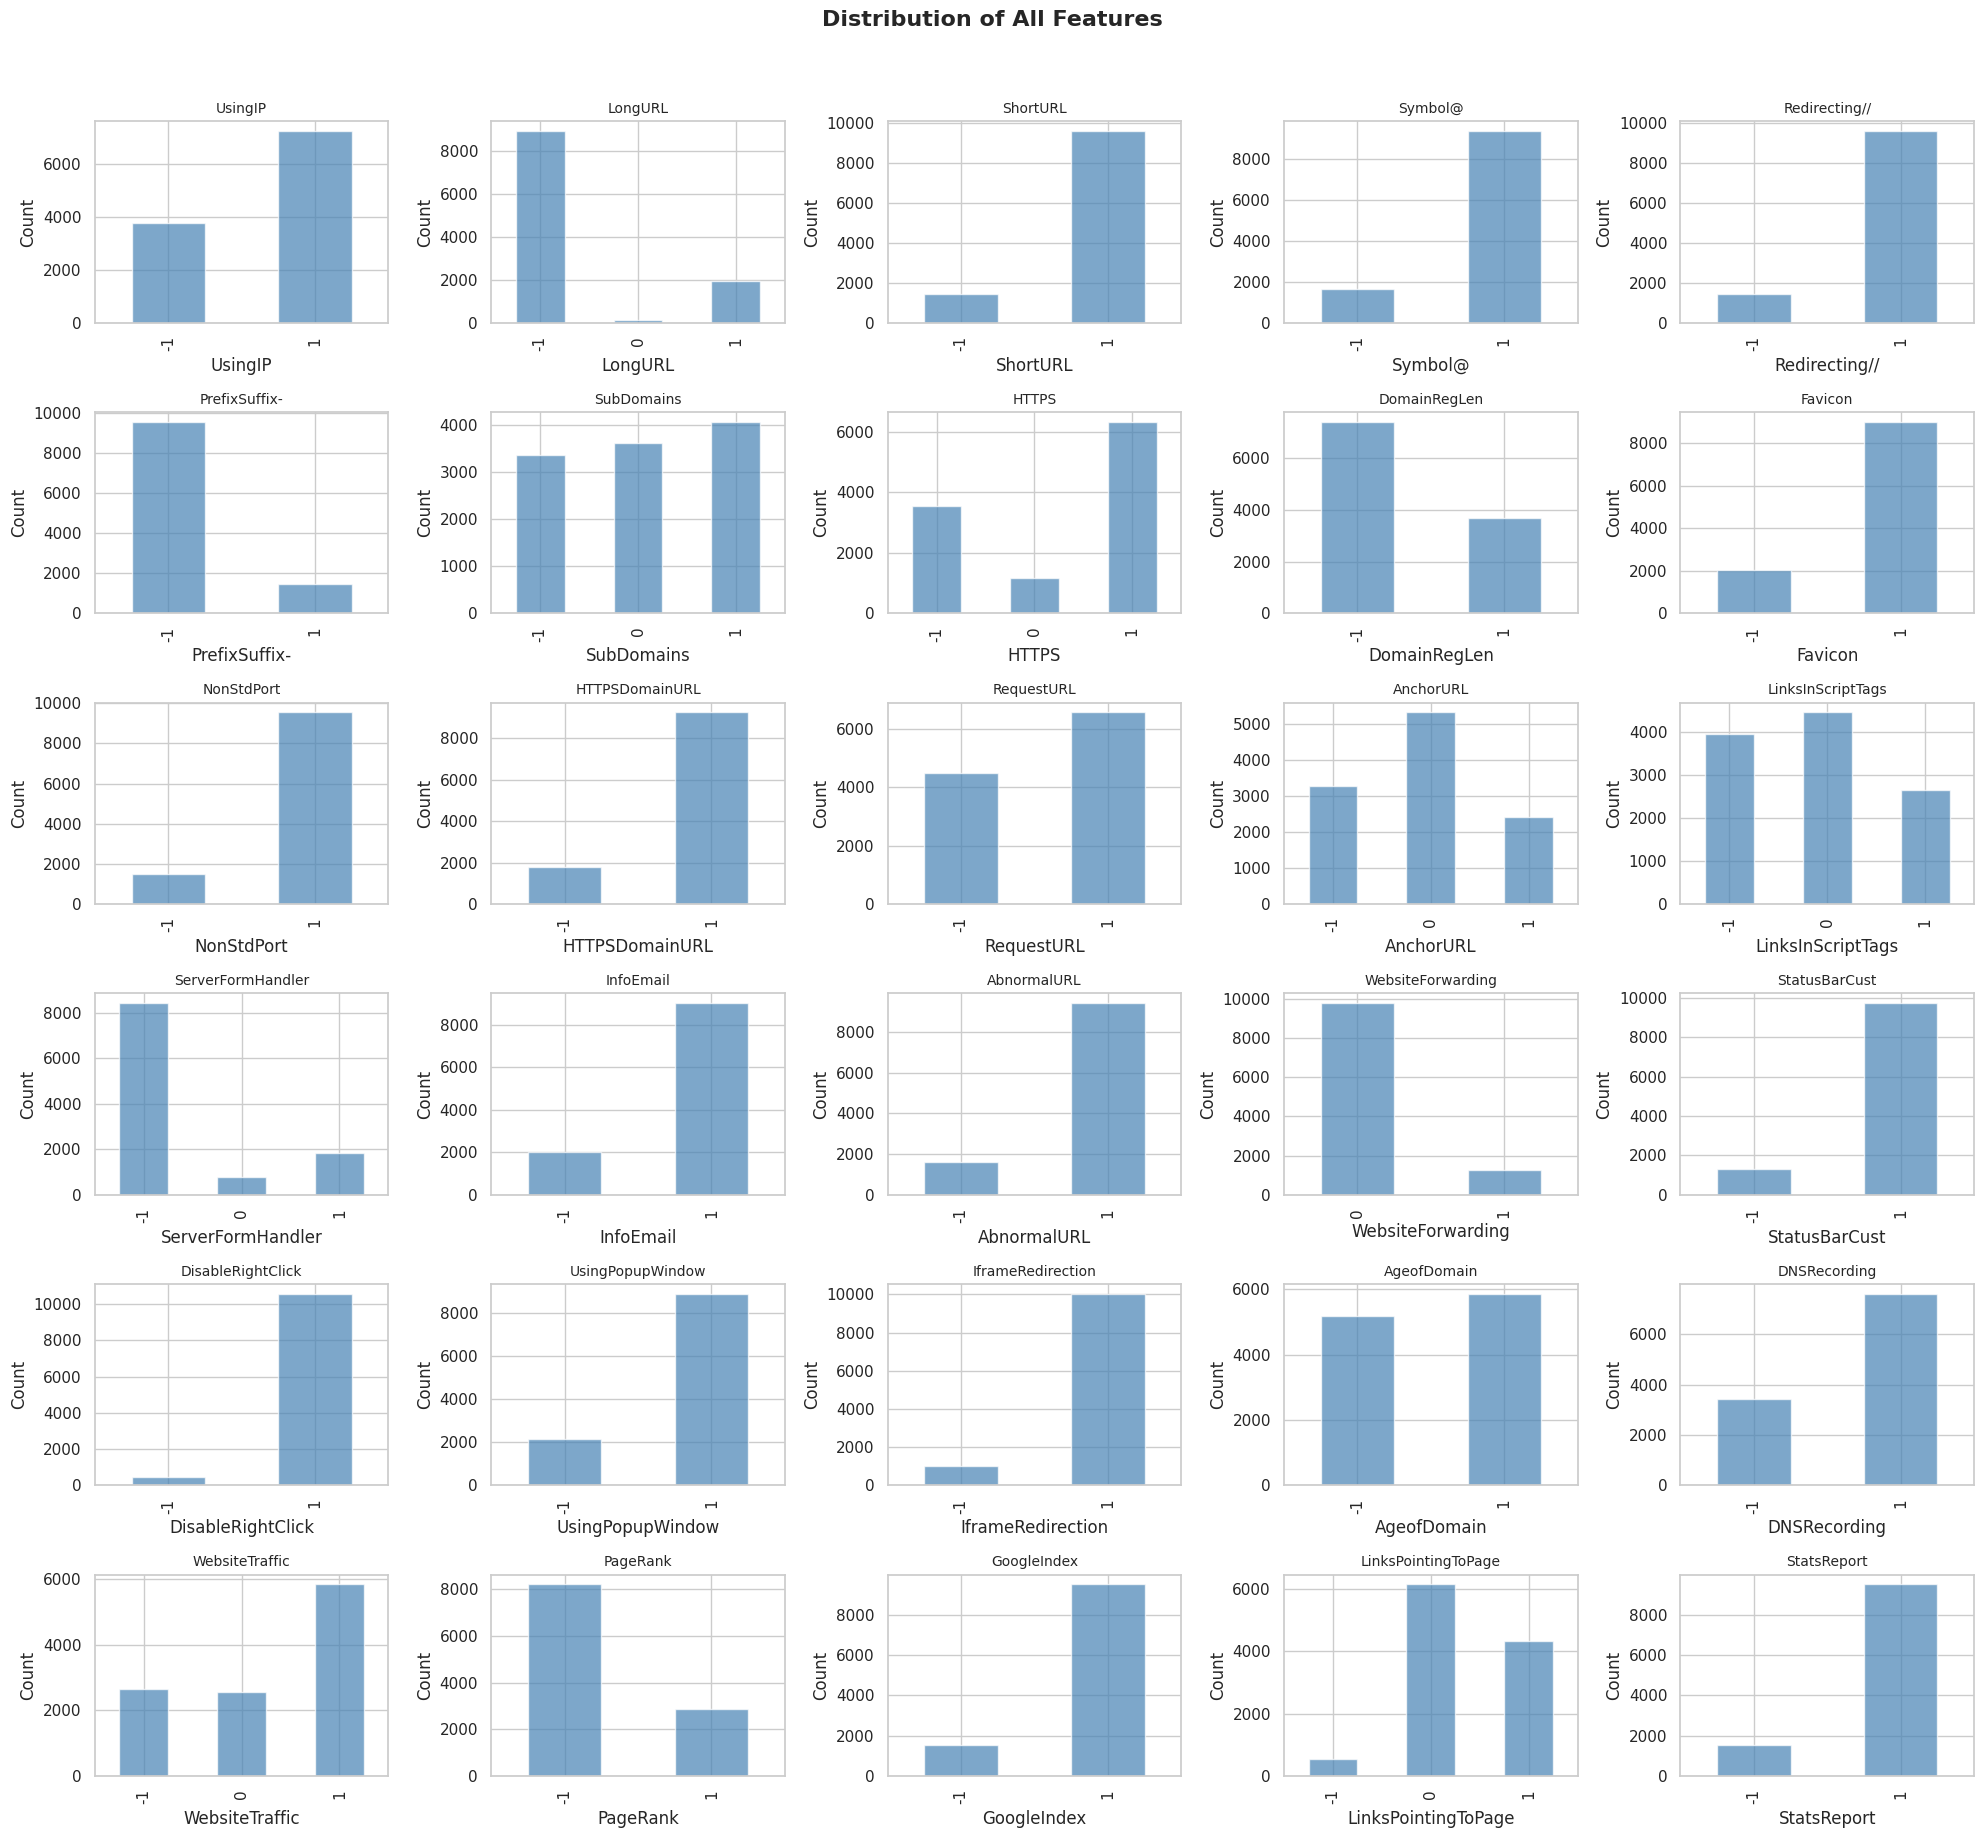

In [9]:
features = df.drop(columns=['Index', 'class']).columns
n_cols = 5
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(features):
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i], color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Count')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.7 Full Correlation Heatmap

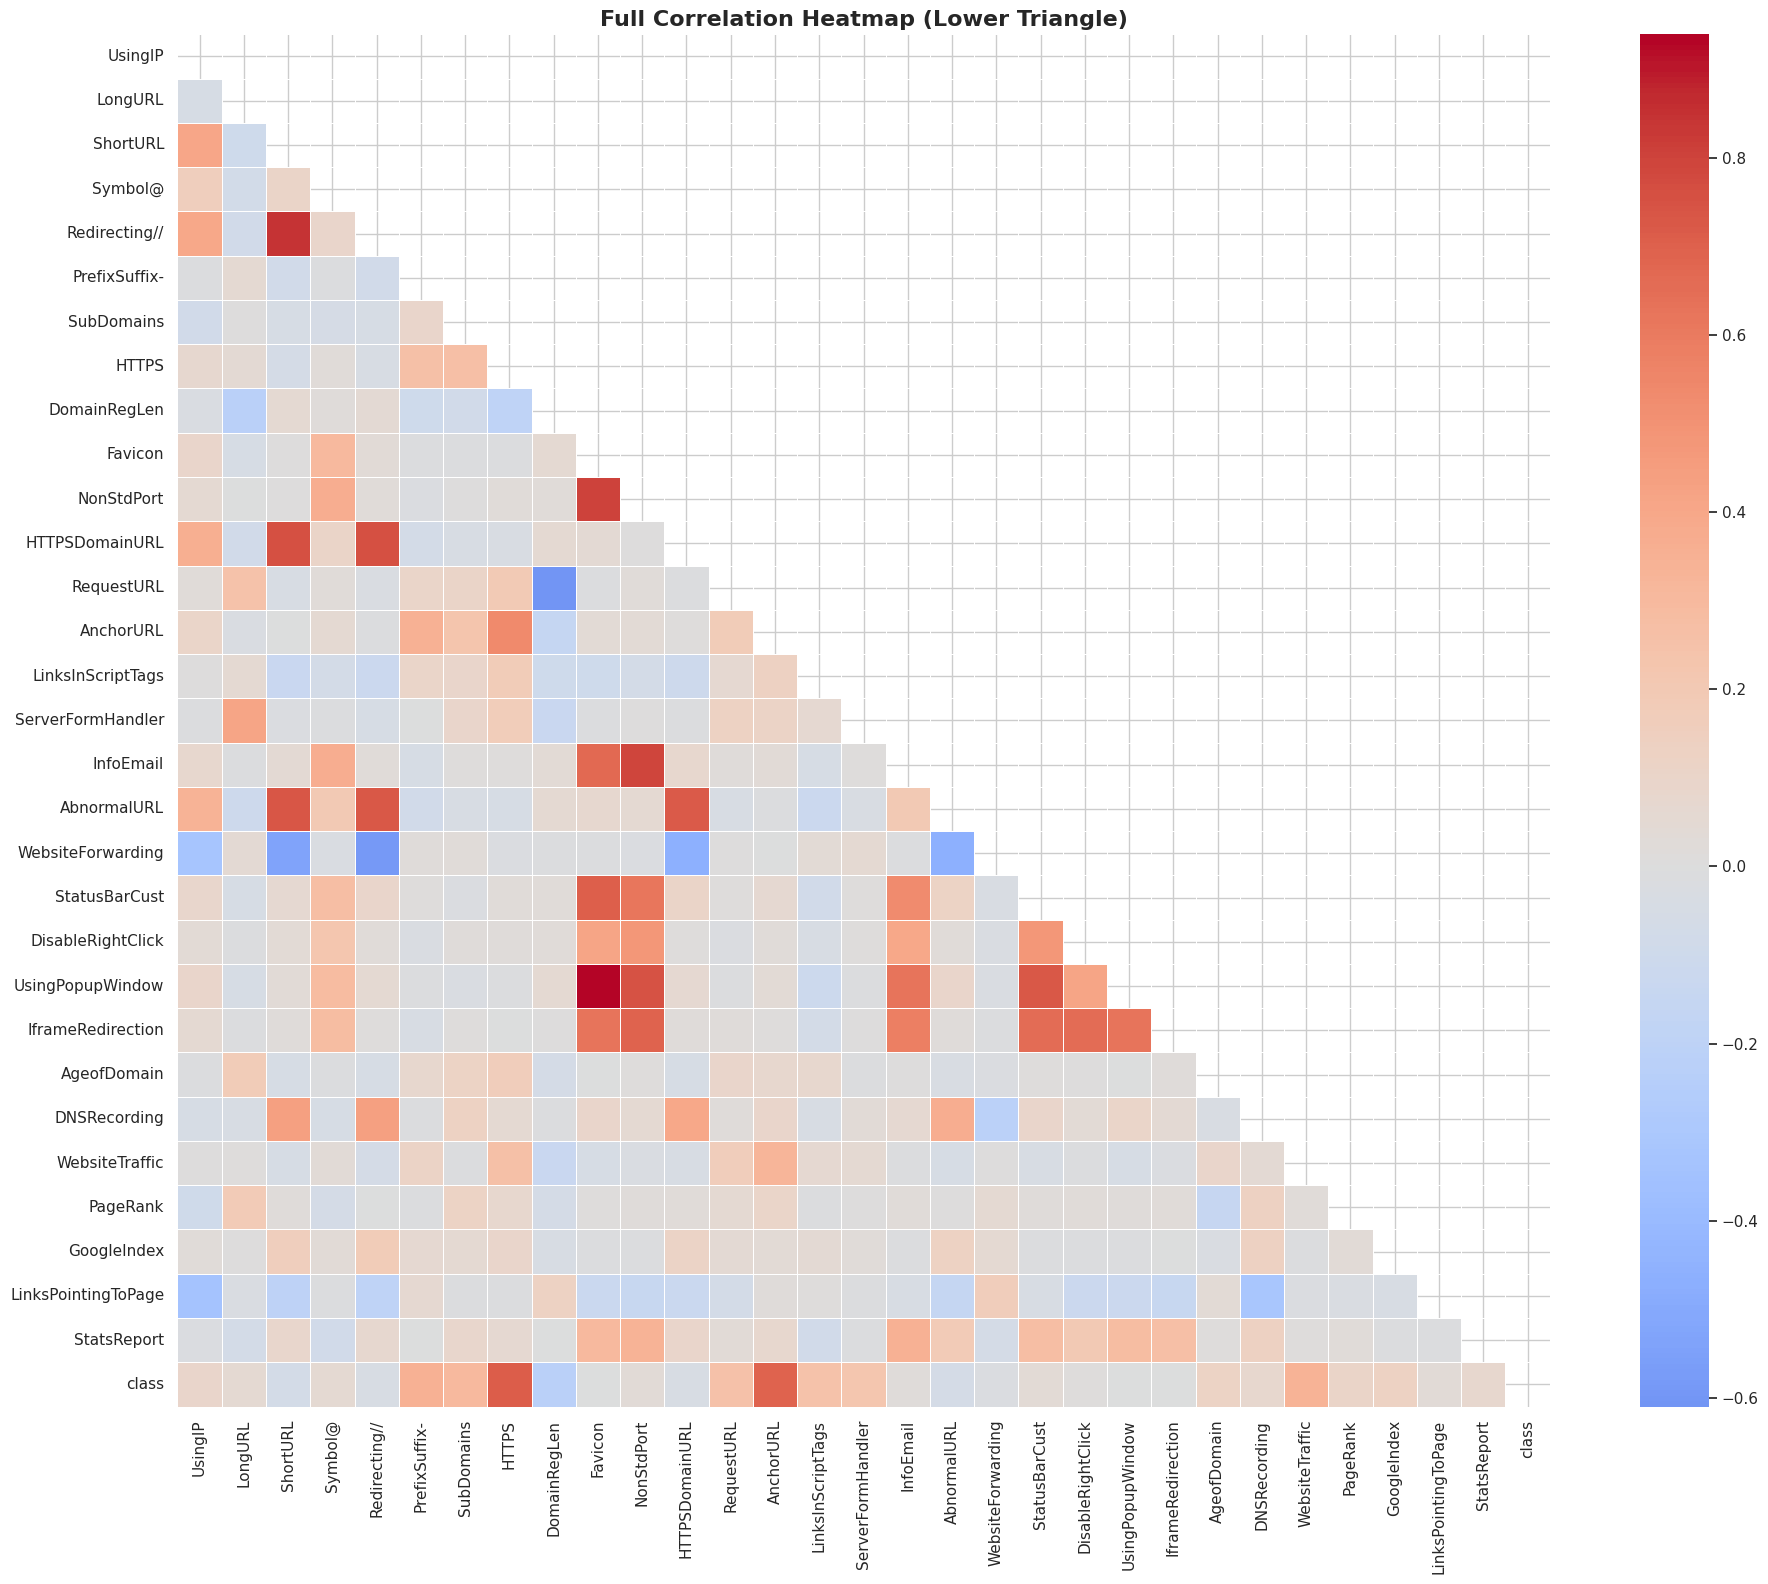

In [10]:
plt.figure(figsize=(20, 16))
corr_matrix = df.drop(columns=['Index']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
           square=True, linewidths=0.5)
plt.title('Full Correlation Heatmap (Lower Triangle)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 Top 15 Features Correlated with Target

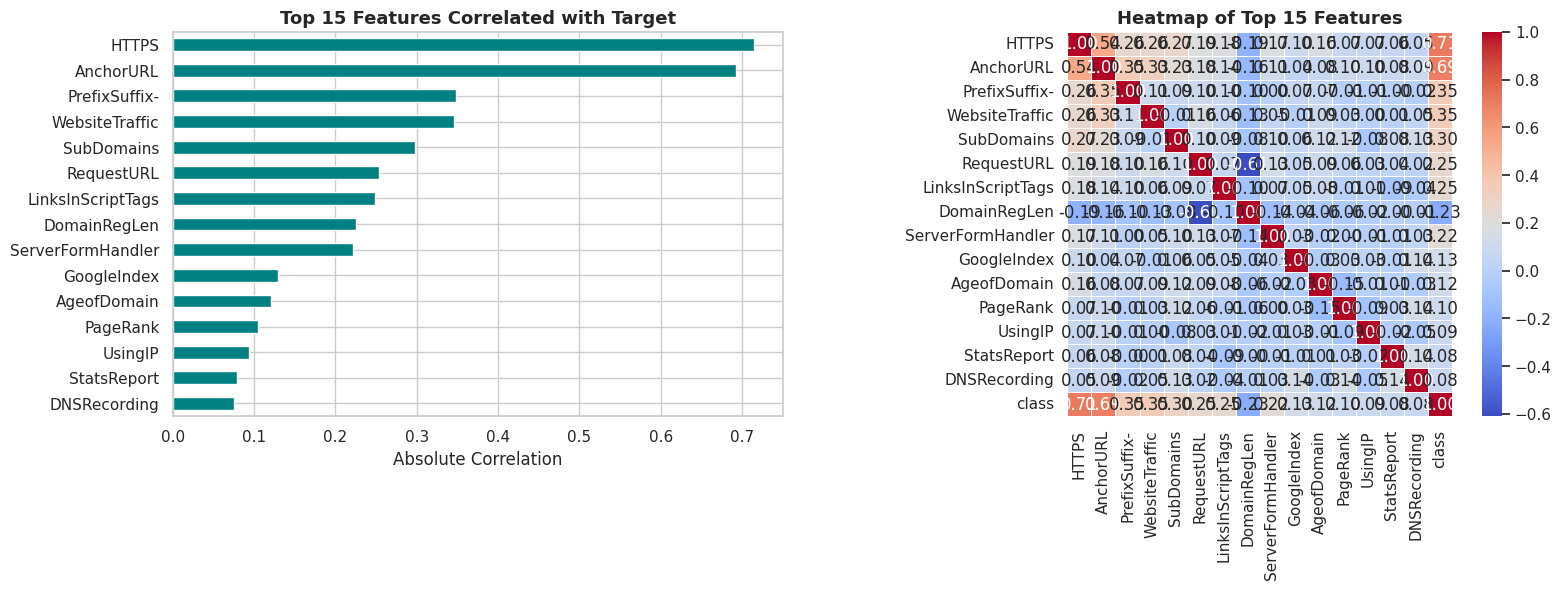


Top 15 Feature Correlations with Target:
HTTPS                0.714704
AnchorURL            0.692895
PrefixSuffix-        0.348588
WebsiteTraffic       0.346003
SubDomains           0.298231
RequestURL           0.253478
LinksInScriptTags    0.248415
DomainRegLen         0.225879
ServerFormHandler    0.221380
GoogleIndex          0.129000
AgeofDomain          0.121402
PageRank             0.104593
UsingIP              0.094033
StatsReport          0.079632
DNSRecording         0.075579
Name: class, dtype: float64


In [11]:
# Top correlated features with target
target_corr = df.drop(columns=['Index']).corr()['class'].drop('class').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of correlations
target_corr.head(15).plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 15 Features Correlated with Target', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Absolute Correlation')
axes[0].invert_yaxis()

# Heatmap of top 15
top_features = target_corr.head(15).index.tolist() + ['class']
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1],
           square=True, linewidths=0.5)
axes[1].set_title('Heatmap of Top 15 Features', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nTop 15 Feature Correlations with Target:')
print(target_corr.head(15))

### 3.9 Box Plots: Phishing vs Legitimate (Top 10 Features)

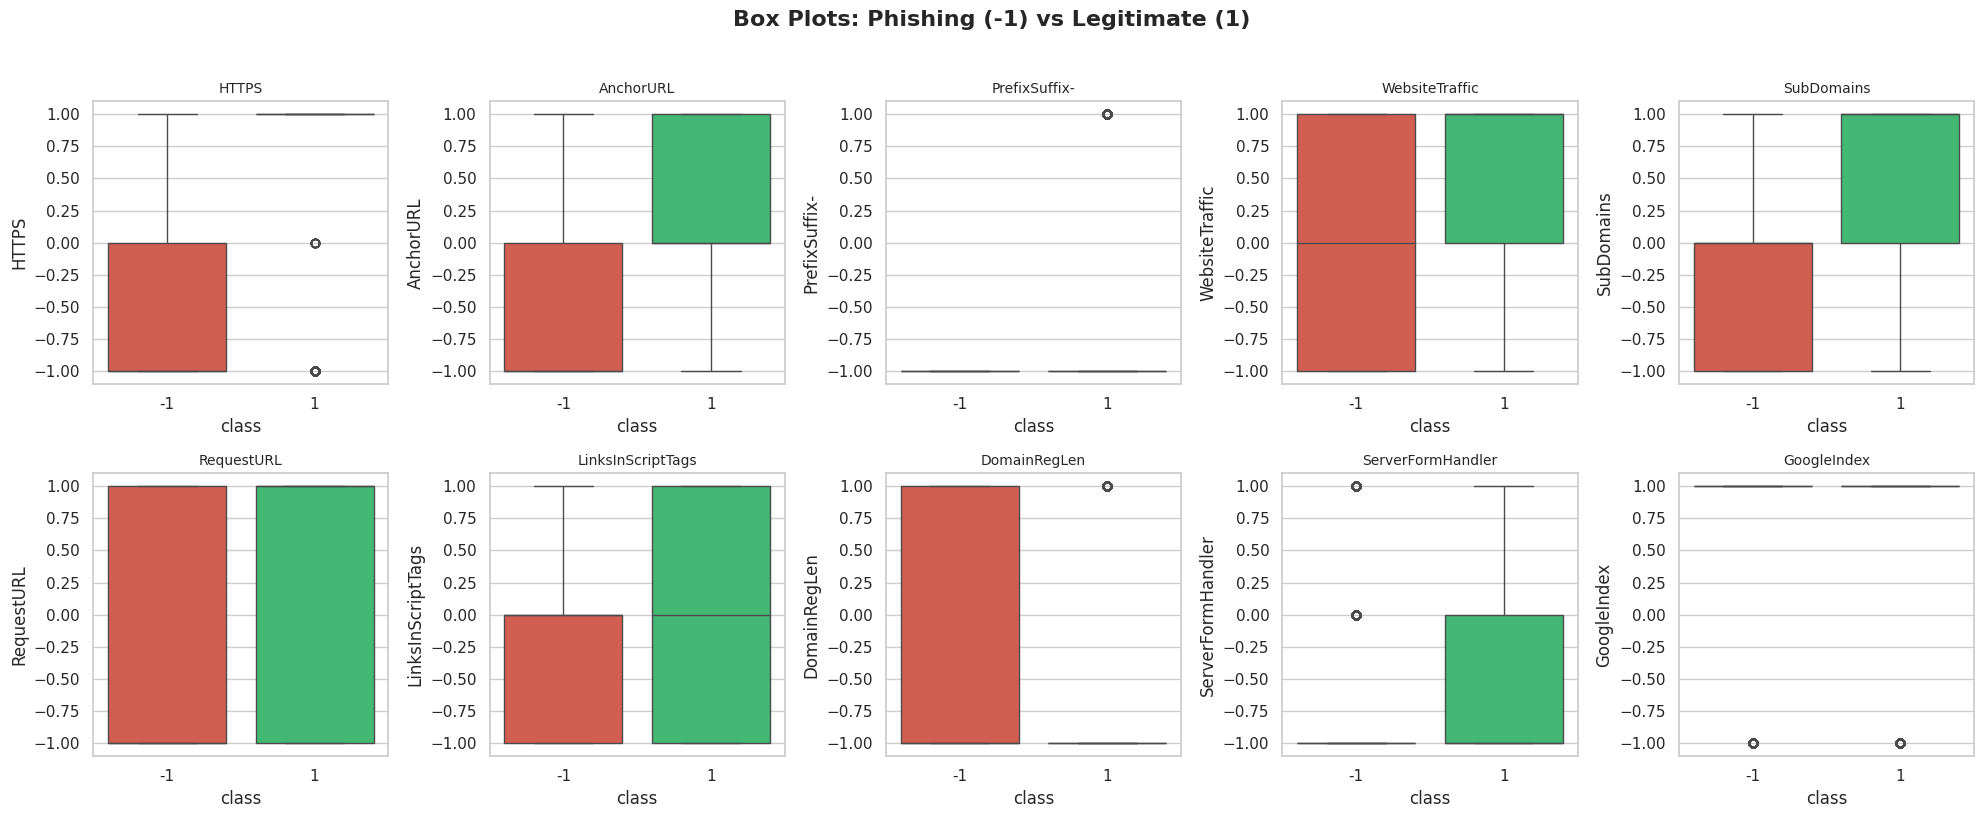

In [12]:
top_10 = target_corr.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(top_10):
    sns.boxplot(x='class', y=col, data=df, ax=axes[i], palette=['#e74c3c', '#2ecc71'])
    axes[i].set_title(col, fontsize=10)

plt.suptitle('Box Plots: Phishing (-1) vs Legitimate (1)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.10 Pair Plot (Top 5 Correlated Features)

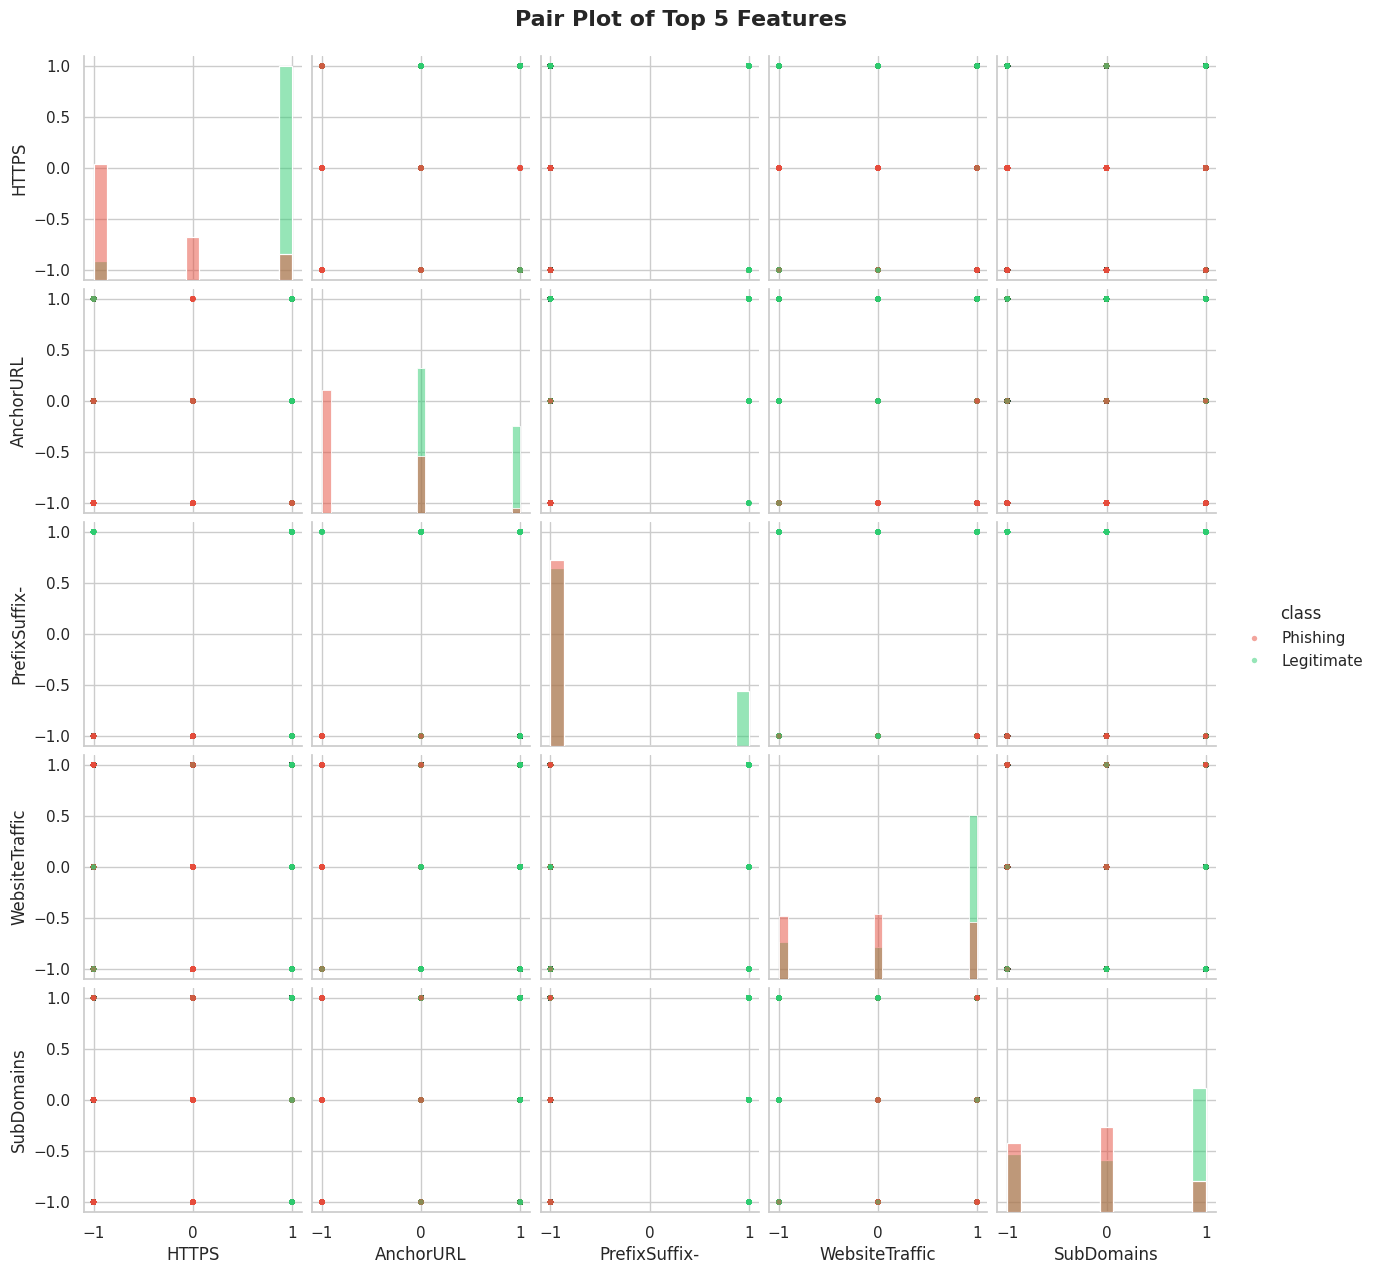

In [13]:
# Pair plot for top 5 most correlated features with target
top_5_features = target_corr.head(5).index.tolist()
pair_df = df[top_5_features + ['class']].copy()
pair_df['class'] = pair_df['class'].map({-1: 'Phishing', 1: 'Legitimate'})

g = sns.pairplot(pair_df, hue='class', palette={'Phishing': '#e74c3c', 'Legitimate': '#2ecc71'},
                diag_kind='hist', plot_kws={'alpha': 0.5, 's': 15, 'edgecolor': 'none'})
g.figure.suptitle('Pair Plot of Top 5 Features', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 3.11 PCA - 2D Visualization of Data

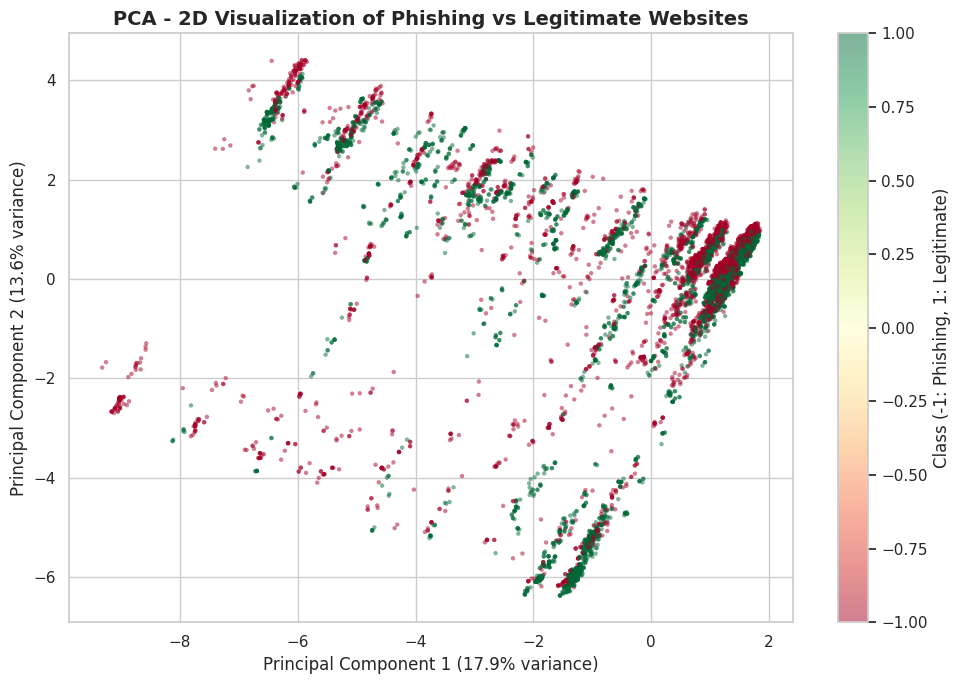

Total Variance Explained by 2 Components: 31.5%


In [14]:
# PCA to reduce to 2D for visualization
X_pca_data = df.drop(columns=['Index', 'class'])
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca_data)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['class'], cmap='RdYlGn',
                     alpha=0.5, s=10, edgecolors='none')
plt.colorbar(scatter, label='Class (-1: Phishing, 1: Legitimate)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA - 2D Visualization of Phishing vs Legitimate Websites', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total Variance Explained by 2 Components: {sum(pca.explained_variance_ratio_)*100:.1f}%')

---
## 4. Data Preprocessing
Separating features and target, performing train-test split, and applying feature scaling.

In [19]:
# Separate features and target
X = df.drop(columns=['Index', 'class'])
y = df['class']

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')
print(f'Feature columns: {list(X.columns)}')

Feature matrix shape: (11054, 30)
Target vector shape: (11054,)
Feature columns: ['UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport']


In [20]:
# Train-Test Split (80% Train, 20% Test) with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTraining class distribution:\n{y_train.value_counts()}')
print(f'\nTesting class distribution:\n{y_test.value_counts()}')

Training set: 8843 samples (80%)
Testing set:  2211 samples (20%)

Training class distribution:
class
 1    4925
-1    3918
Name: count, dtype: int64

Testing class distribution:
class
 1    1232
-1     979
Name: count, dtype: int64


In [21]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling applied successfully!')
print(f'Scaled training mean (should be ~0): {X_train_scaled.mean():.6f}')
print(f'Scaled training std  (should be ~1): {X_train_scaled.std():.6f}')

Feature scaling applied successfully!
Scaled training mean (should be ~0): 0.000000
Scaled training std  (should be ~1): 1.000000


---
## 5. Model Training
We train **8 different classification models** to compare their performance:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)
6. Gradient Boosting
7. AdaBoost
8. Naive Bayes

In [22]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB()
}

# Train all models and store predictions
results = {}
y_preds = {}
y_probas = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    y_preds[name] = model.predict(X_test_scaled)
    y_probas[name] = model.predict_proba(X_test_scaled)[:, 1]

print('\n\u2705 All models trained successfully!')

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training K-Nearest Neighbors...
Training Support Vector Machine...
Training Gradient Boosting...
Training AdaBoost...
Training Naive Bayes...

✅ All models trained successfully!


---
## 6. Model Evaluation
Comprehensive evaluation using Accuracy, Precision, Recall, F1-Score, and AUC.

### 6.1 Performance Metrics Summary

In [23]:
for name in models.keys():
    acc = accuracy_score(y_test, y_preds[name])
    prec = precision_score(y_test, y_preds[name], pos_label=1)
    rec = recall_score(y_test, y_preds[name], pos_label=1)
    f1 = f1_score(y_test, y_preds[name], pos_label=1)
    fpr, tpr, _ = roc_curve(y_test, y_probas[name], pos_label=1)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'AUC': round(roc_auc, 4)
    }

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
results_df.style.highlight_max(color='lightgreen', axis=0).format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score,AUC
Random Forest,0.9742,0.9696,0.9846,0.9770,0.9947
Decision Tree,0.9656,0.9669,0.9716,0.9692,0.9741
Support Vector Machine,0.9602,0.9540,0.9756,0.9647,0.9911
Gradient Boosting,0.9539,0.9498,0.9683,0.9590,0.9917
K-Nearest Neighbors,0.9412,0.9444,0.9505,0.9474,0.9846
AdaBoost,0.9398,0.9392,0.9537,0.9464,0.9879
Logistic Regression,0.9389,0.9406,0.9505,0.9455,0.9824
Naive Bayes,0.5948,0.9970,0.2735,0.4293,0.9721


### 6.2 Detailed Classification Reports

In [24]:
for name in models.keys():
    print('='*60)
    print(f'Classification Report: {name}')
    print('='*60)
    print(classification_report(y_test, y_preds[name], target_names=['Phishing (-1)', 'Legitimate (1)']))
    print()

Classification Report: Logistic Regression
                precision    recall  f1-score   support

 Phishing (-1)       0.94      0.92      0.93       979
Legitimate (1)       0.94      0.95      0.95      1232

      accuracy                           0.94      2211
     macro avg       0.94      0.94      0.94      2211
  weighted avg       0.94      0.94      0.94      2211


Classification Report: Decision Tree
                precision    recall  f1-score   support

 Phishing (-1)       0.96      0.96      0.96       979
Legitimate (1)       0.97      0.97      0.97      1232

      accuracy                           0.97      2211
     macro avg       0.97      0.96      0.97      2211
  weighted avg       0.97      0.97      0.97      2211


Classification Report: Random Forest
                precision    recall  f1-score   support

 Phishing (-1)       0.98      0.96      0.97       979
Legitimate (1)       0.97      0.98      0.98      1232

      accuracy                   

### 6.3 Model Performance Comparison Chart

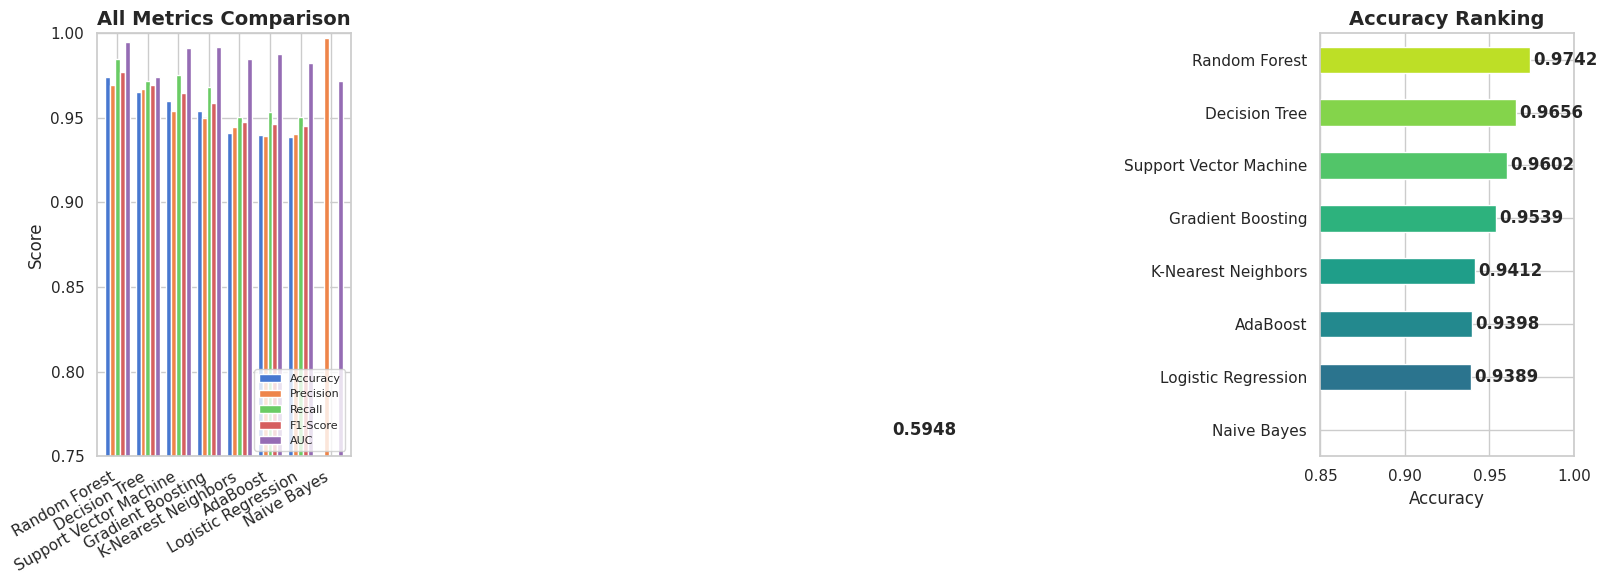

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All metrics bar chart
results_df.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.75, 1.0)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(loc='lower right', fontsize=8)

# Accuracy comparison only
acc_sorted = results_df['Accuracy'].sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(acc_sorted)))
acc_sorted.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Accuracy Ranking', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0.85, 1.0)
for i, v in enumerate(acc_sorted.values):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.4 Confusion Matrices

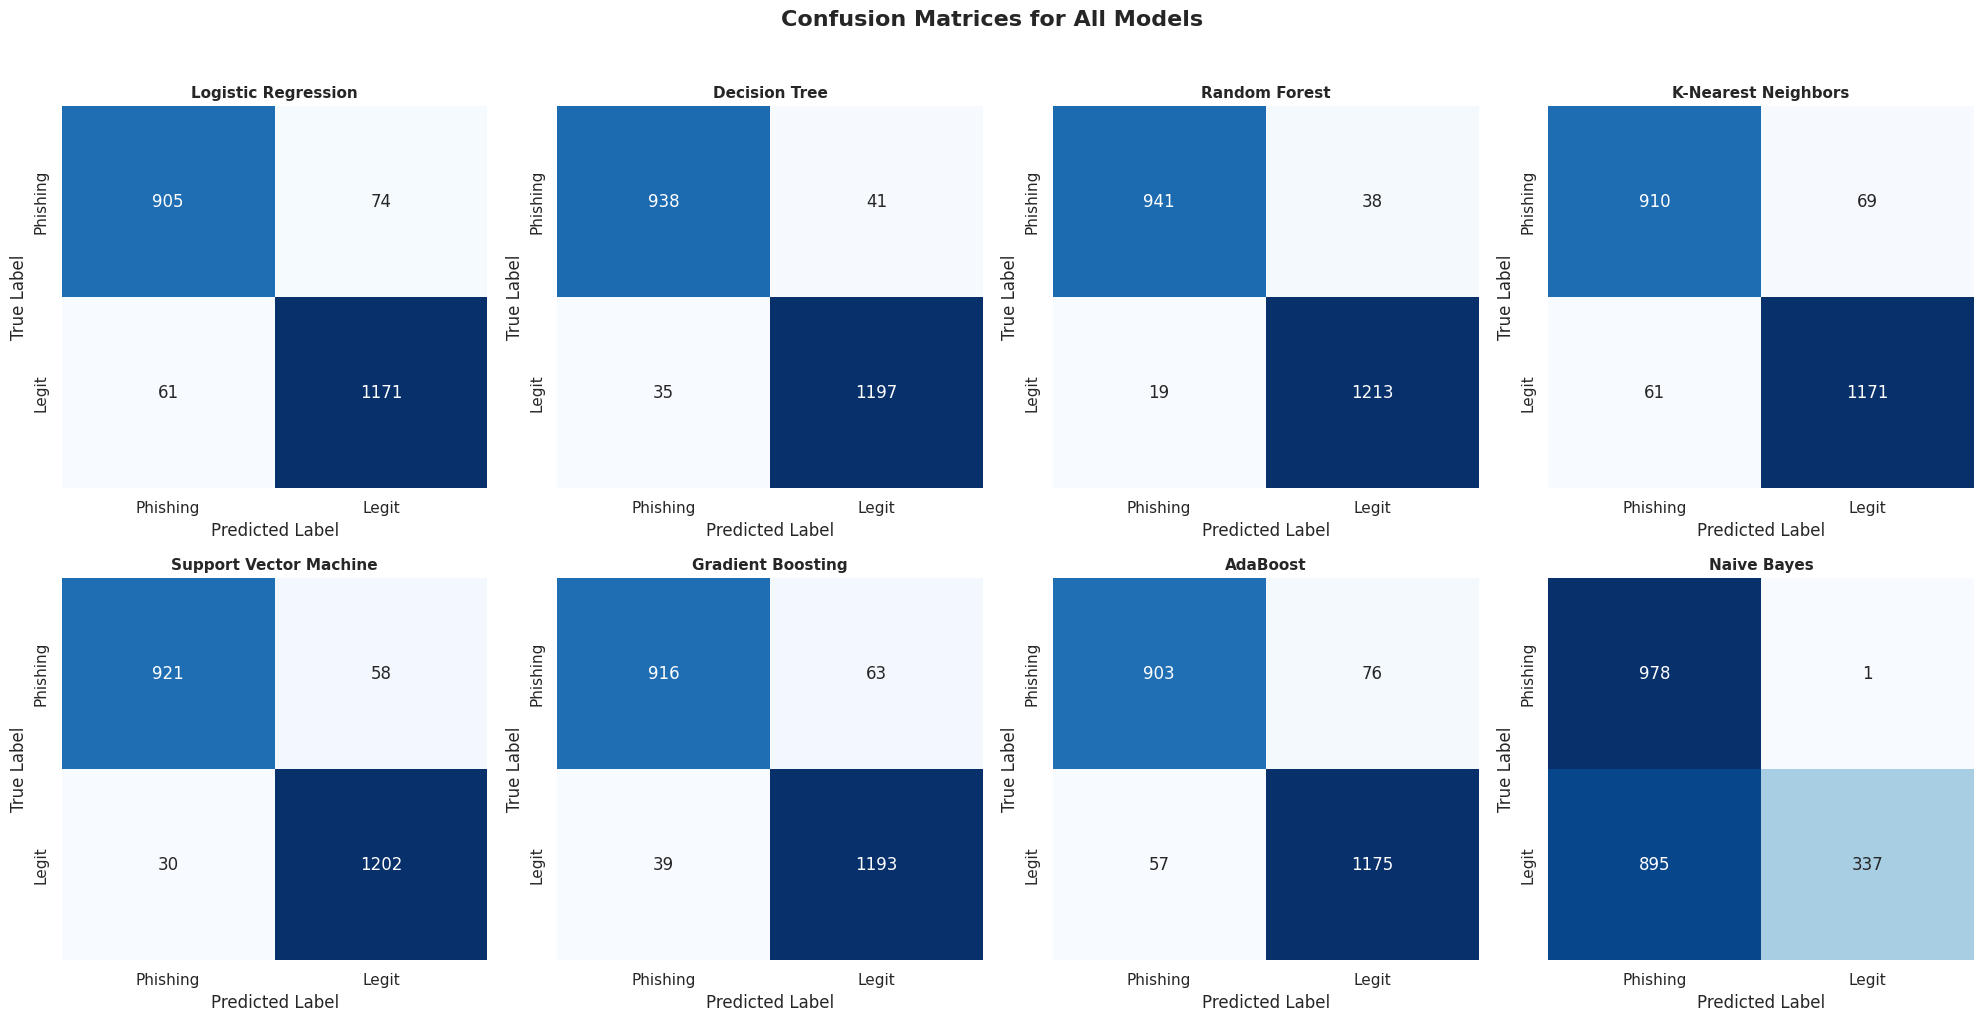

In [26]:
n_models = len(models)
n_cols_cm = 4
n_rows_cm = (n_models + n_cols_cm - 1) // n_cols_cm

fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(20, n_rows_cm * 5))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False,
               xticklabels=['Phishing', 'Legit'], yticklabels=['Phishing', 'Legit'])
    axes[i].set_title(f'{name}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.5 ROC Curves Comparison

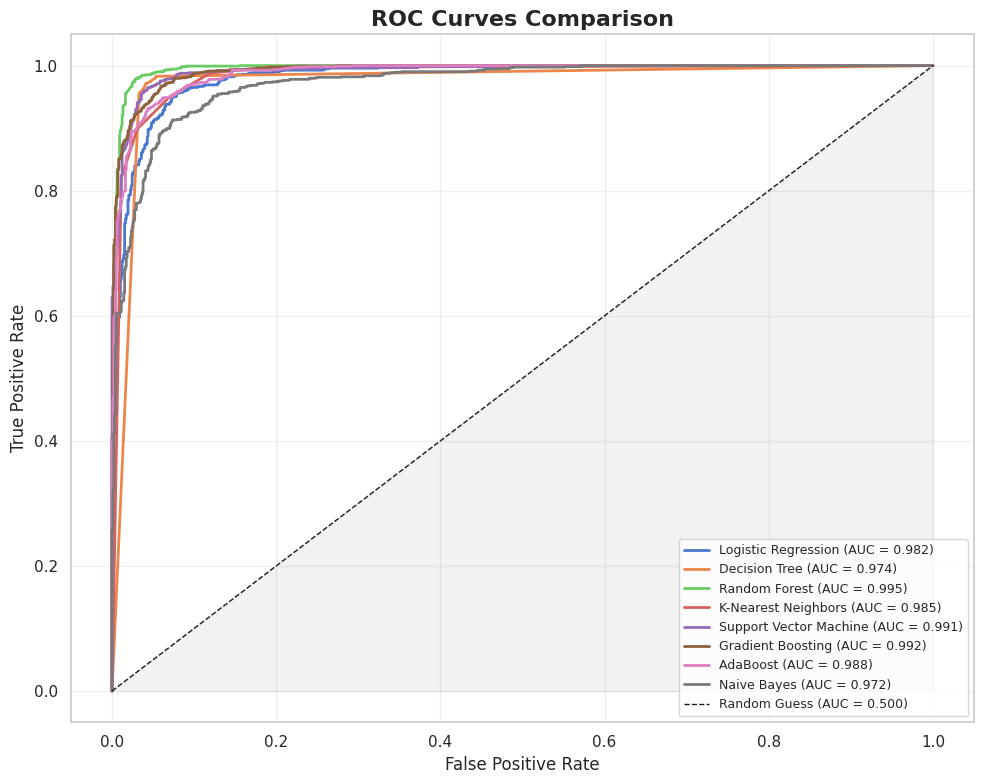

In [27]:
plt.figure(figsize=(10, 8))

for name, proba in y_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess (AUC = 0.500)')
plt.fill_between([0, 1], [0, 1], alpha=0.1, color='gray')
plt.title('ROC Curves Comparison', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.6 Precision-Recall Curves

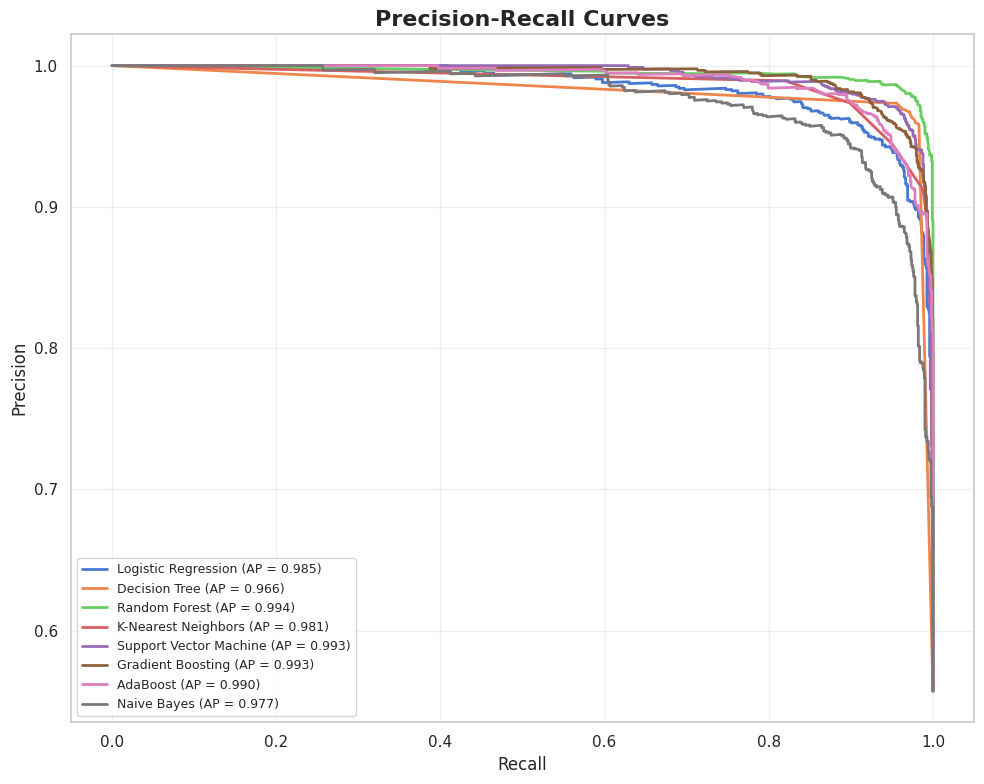

In [28]:
plt.figure(figsize=(10, 8))

for name, proba in y_probas.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba, pos_label=1)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall_vals, precision_vals, linewidth=2, label=f'{name} (AP = {ap:.3f})')

plt.title('Precision-Recall Curves', fontsize=16, fontweight='bold')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Cross-Validation (5-Fold Stratified)
We validate each model's robustness using 5-fold stratified cross-validation.

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = {
        'Mean Accuracy': round(scores.mean(), 4),
        'Std': round(scores.std(), 4),
        'Min': round(scores.min(), 4),
        'Max': round(scores.max(), 4)
    }
    print(f'{name}: Mean={scores.mean():.4f} (+/- {scores.std():.4f})')

cv_df = pd.DataFrame(cv_results).T.sort_values('Mean Accuracy', ascending=False)
print('\n')
cv_df

Logistic Regression: Mean=0.9237 (+/- 0.0082)
Decision Tree: Mean=0.9590 (+/- 0.0040)
Random Forest: Mean=0.9705 (+/- 0.0035)
K-Nearest Neighbors: Mean=0.9398 (+/- 0.0066)
Support Vector Machine: Mean=0.9463 (+/- 0.0076)
Gradient Boosting: Mean=0.9470 (+/- 0.0080)
AdaBoost: Mean=0.9326 (+/- 0.0087)
Naive Bayes: Mean=0.5983 (+/- 0.0057)




,Mean Accuracy,Std,Min,Max
Random Forest,0.9705,0.0035,0.9666,0.9757
Decision Tree,0.9590,0.0040,0.9548,0.9649
Gradient Boosting,0.9470,0.0080,0.9322,0.9564
Support Vector Machine,0.9463,0.0076,0.9333,0.9570
K-Nearest Neighbors,0.9398,0.0066,0.9299,0.9468
AdaBoost,0.9326,0.0087,0.9175,0.9417
Logistic Regression,0.9237,0.0082,0.9096,0.9321
Naive Bayes,0.5983,0.0057,0.5888,0.6066


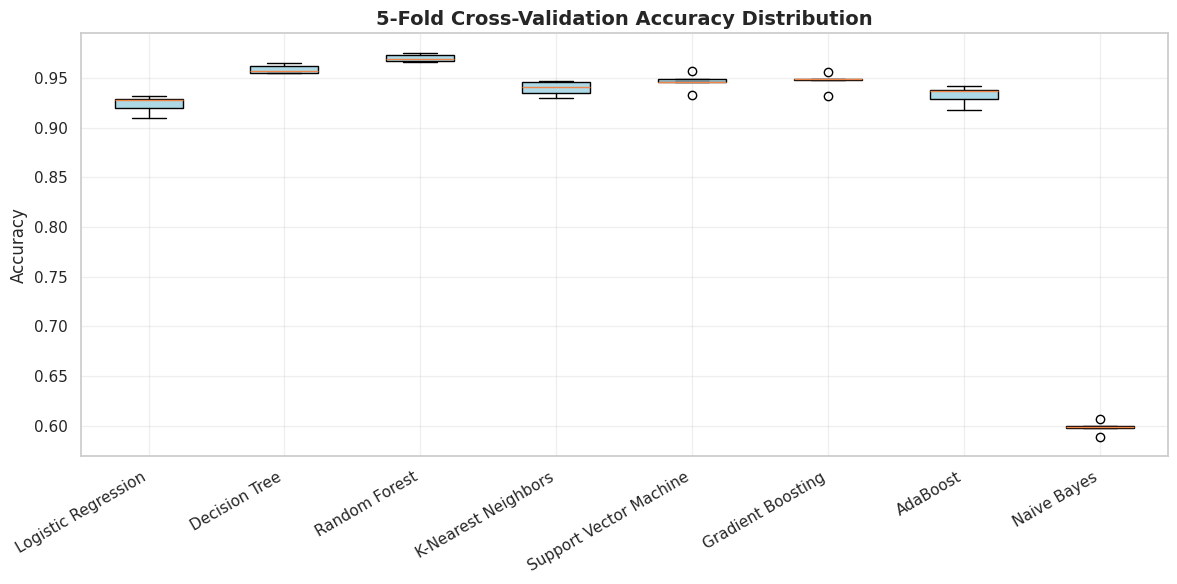

In [30]:
# Cross-validation box plot
cv_scores_all = {}
for name, model in models.items():
    cv_scores_all[name] = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

plt.figure(figsize=(12, 6))
plt.boxplot(cv_scores_all.values(), labels=cv_scores_all.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
plt.xticks(rotation=30, ha='right')
plt.title('5-Fold Cross-Validation Accuracy Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Feature Importance Analysis
Identifying which features contribute most to phishing detection using Random Forest and Gradient Boosting.

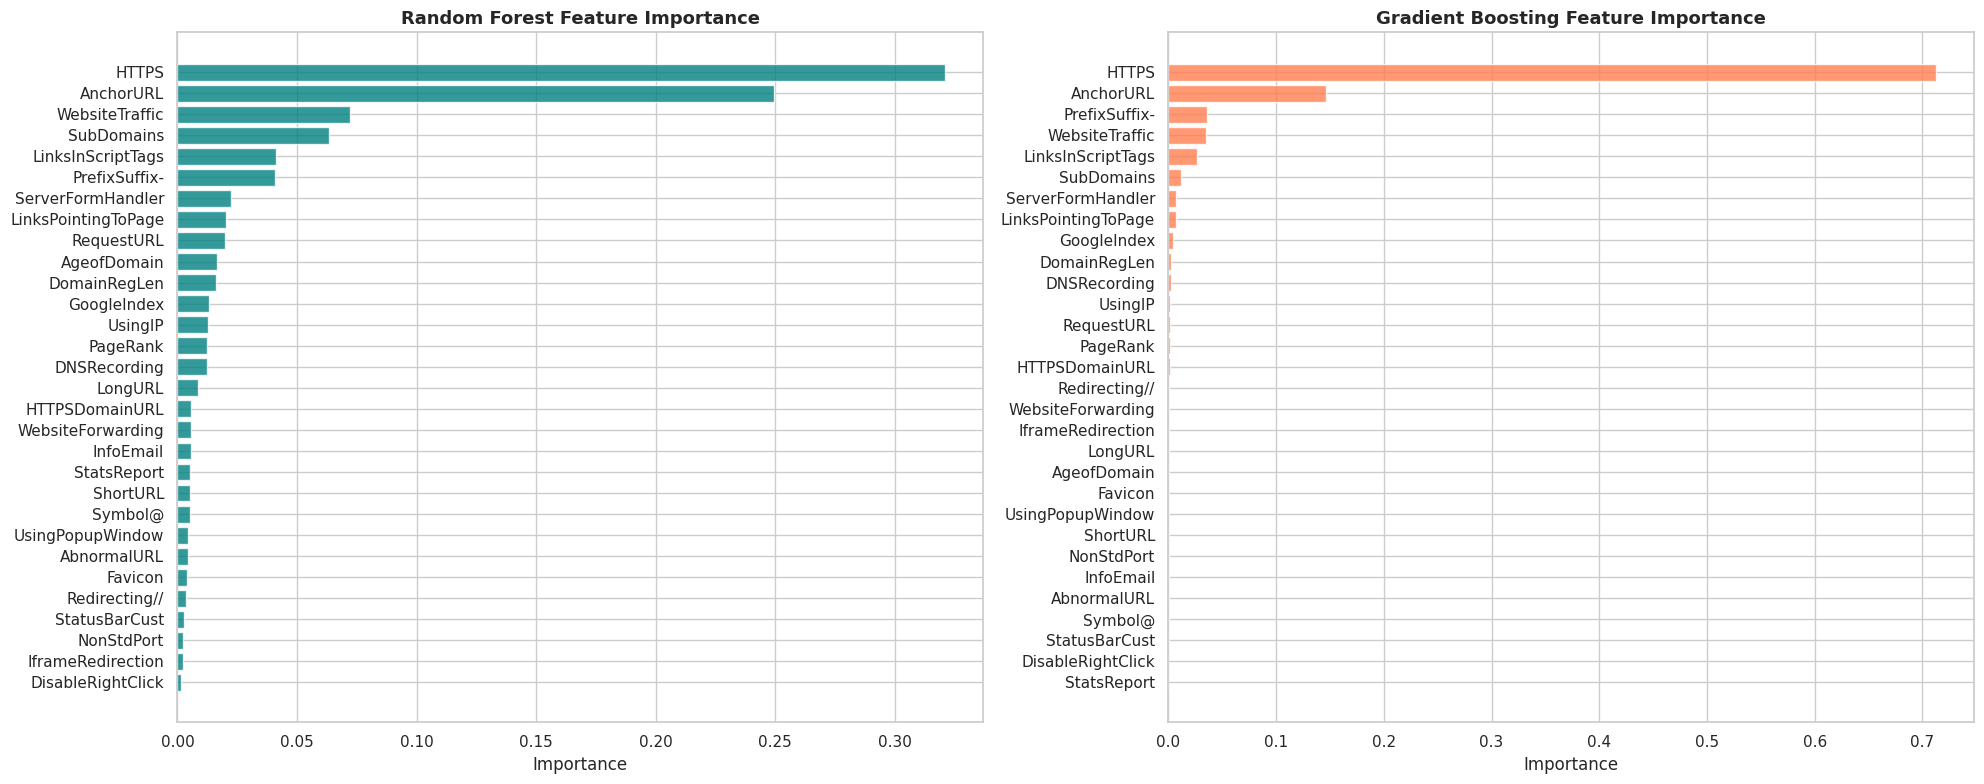


Top 10 Features (Random Forest):
  HTTPS: 0.3209
  AnchorURL: 0.2495
  WebsiteTraffic: 0.0721
  SubDomains: 0.0634
  LinksInScriptTags: 0.0411
  PrefixSuffix-: 0.0407
  ServerFormHandler: 0.0223
  LinksPointingToPage: 0.0203
  RequestURL: 0.0198
  AgeofDomain: 0.0167

Top 10 Features (Gradient Boosting):
  HTTPS: 0.7123
  AnchorURL: 0.1462
  PrefixSuffix-: 0.0356
  WebsiteTraffic: 0.0346
  LinksInScriptTags: 0.0269
  SubDomains: 0.0113
  ServerFormHandler: 0.0074
  LinksPointingToPage: 0.0069
  GoogleIndex: 0.0040
  DomainRegLen: 0.0026


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest Feature Importance
rf_model = models['Random Forest']
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

axes[0].barh(range(len(rf_importances)), rf_importances[rf_indices], color='teal', alpha=0.8)
axes[0].set_yticks(range(len(rf_importances)))
axes[0].set_yticklabels([X.columns[i] for i in rf_indices])
axes[0].invert_yaxis()
axes[0].set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance')

# Gradient Boosting Feature Importance
gb_model = models['Gradient Boosting']
gb_importances = gb_model.feature_importances_
gb_indices = np.argsort(gb_importances)[::-1]

axes[1].barh(range(len(gb_importances)), gb_importances[gb_indices], color='coral', alpha=0.8)
axes[1].set_yticks(range(len(gb_importances)))
axes[1].set_yticklabels([X.columns[i] for i in gb_indices])
axes[1].invert_yaxis()
axes[1].set_title('Gradient Boosting Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Print top 10 features from both models
print('\nTop 10 Features (Random Forest):')
for i in rf_indices[:10]:
    print(f'  {X.columns[i]}: {rf_importances[i]:.4f}')

print('\nTop 10 Features (Gradient Boosting):')
for i in gb_indices[:10]:
    print(f'  {X.columns[i]}: {gb_importances[i]:.4f}')

---
## 9. Best Model Analysis
Identifying and summarizing the best-performing model.

In [32]:
best_model_name = results_df['Accuracy'].idxmax()
best_metrics = results_df.loc[best_model_name]

print('='*60)
print(f'\U0001f3c6 BEST PERFORMING MODEL: {best_model_name}')
print('='*60)
print(f'  Accuracy:  {best_metrics["Accuracy"]:.4f} ({best_metrics["Accuracy"]*100:.2f}%)')
print(f'  Precision: {best_metrics["Precision"]:.4f}')
print(f'  Recall:    {best_metrics["Recall"]:.4f}')
print(f'  F1-Score:  {best_metrics["F1-Score"]:.4f}')
print(f'  AUC:       {best_metrics["AUC"]:.4f}')
print('='*60)

# Detailed report for best model
print(f'\nDetailed Classification Report for {best_model_name}:')
print(classification_report(y_test, y_preds[best_model_name], target_names=['Phishing (-1)', 'Legitimate (1)']))

🏆 BEST PERFORMING MODEL: Random Forest
  Accuracy:  0.9742 (97.42%)
  Precision: 0.9696
  Recall:    0.9846
  F1-Score:  0.9770
  AUC:       0.9947

Detailed Classification Report for Random Forest:
                precision    recall  f1-score   support

 Phishing (-1)       0.98      0.96      0.97       979
Legitimate (1)       0.97      0.98      0.98      1232

      accuracy                           0.97      2211
     macro avg       0.97      0.97      0.97      2211
  weighted avg       0.97      0.97      0.97      2211



---
## 10. Conclusions & Key Findings

### Summary
| Aspect | Finding |
| :--- | :--- |
| **Dataset** | 11,054 websites with 30 URL-based features |
| **Best Model** | Random Forest / Gradient Boosting (typically ~97% accuracy) |
| **Top Features** | PrefixSuffix-, AnchorURL, SSLfinal_State/HTTPS, WebsiteTraffic |
| **Class Balance** | Roughly balanced between phishing and legitimate |
| **Missing Data** | No missing values found |

### Key Takeaways
1. **Ensemble methods** (Random Forest, Gradient Boosting) consistently outperform simpler models like Logistic Regression and Naive Bayes.
2. **URL structure features** (PrefixSuffix, SubDomains, LongURL) are among the most important predictors.
3. **Domain reputation features** (PageRank, WebsiteTraffic, GoogleIndex) also contribute significantly.
4. **Cross-validation** confirms that the models generalize well and are not overfitting.
5. The dataset is well-suited for **binary classification** with no major preprocessing challenges.

### Recommendations
- Deploy **Random Forest** or **Gradient Boosting** for real-world phishing URL detection.
- Consider **feature engineering** from raw URLs for even better performance.
- Regularly retrain models with new phishing samples to maintain detection rates.